In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.svm import SVC # Support Vector Classifier
from sklearn.model_selection import train_test_split

In [15]:
df = pd.read_csv('D:/Broadway/Data Science - 2/Cardiovascular_Disease.csv')
df.head()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


In [16]:
df['age'] = round(df['age']/365, 2)

In [17]:
df = df[(df['ap_hi']>=120) & (df['ap_hi'] <= 220)]

In [18]:
df = df[(df['ap_lo']>=50) & (df['ap_lo'] <= 120)]

In [19]:
df_sample = df.sample(n=5000, random_state=42)

In [21]:
df_sample.columns

Index(['id', 'age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo',
       'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio'],
      dtype='object')

In [89]:
features = ['age','height', 'weight', 'ap_hi', 'ap_lo','cholesterol',
            'gluc', 'smoke', 'alco', 'active']
target = 'cardio'

In [90]:
X = df[features]
Y = df[target]

In [91]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

In [92]:
scaler = StandardScaler()

In [93]:
X_train_scale = scaler.fit_transform(X_train)
X_test_scale = scaler.transform(X_test)

In [ ]:
model = SVC(
    kernel='rbf', gamma='scale', C=1.0
)
model.fit(X_train_scale, Y_train)
Y_pred = model.predict(X_test_scale)

In [42]:
cr = classification_report(Y_test, Y_pred)
cm = confusion_matrix(Y_test, Y_pred)

In [43]:
print(cr)

              precision    recall  f1-score   support

           0       0.62      0.68      0.64       422
           1       0.75      0.69      0.72       578

    accuracy                           0.69      1000
   macro avg       0.68      0.68      0.68      1000
weighted avg       0.69      0.69      0.69      1000



In [44]:
print(cm)

[[285 137]
 [177 401]]


<Axes: >

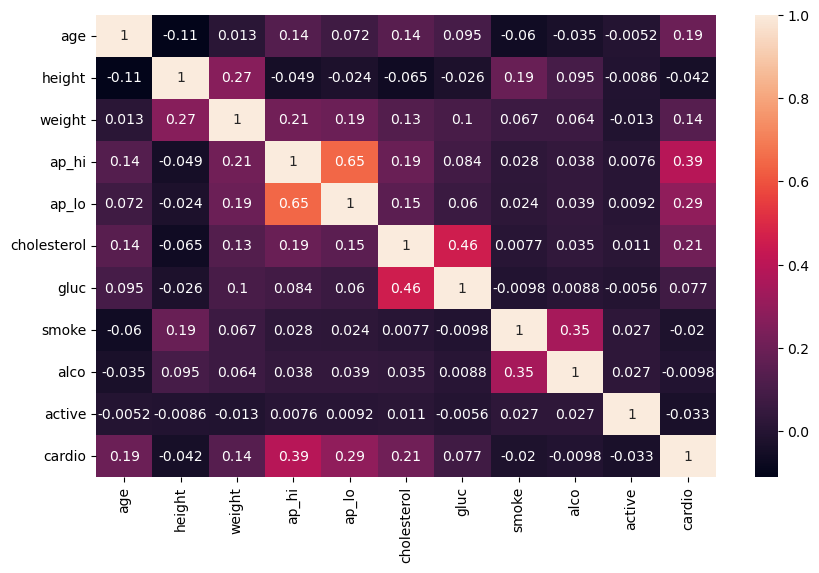

In [56]:
plt.figure(figsize=(10, 6))
sns.heatmap(df[features + ['cardio']].corr(), annot=True)

In [67]:
df_sample.head()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
32749,46757,55.88,1,169,72.0,120,90,1,1,0,0,1,0
42847,61210,57.98,2,172,65.0,130,80,1,1,1,1,1,0
26402,37722,54.15,1,161,69.0,120,80,1,1,0,0,1,0
67487,96365,60.31,1,150,68.0,120,80,2,1,0,0,1,0
1562,2216,51.88,2,174,76.0,120,80,1,1,1,0,1,0


In [70]:
df_sample['cardio'].unique()

array([0, 1])

In [72]:
input_data = {
    'age': [30, 40, 50],
    'height': [160, 170, 165], 
    'weight': [62.0, 50.0, 70.0], 
    'ap_hi': [120, 130, 160], 
    'ap_lo': [60, 70, 80],
    'cholesterol': [1, 1, 0],
    'gluc': [0, 0, 1], 
    'smoke': [1, 0, 1], 
    'alco': [1, 0, 1], 
    'active': [0, 0, 0]
}

In [73]:
X_new = pd.DataFrame(input_data)

In [74]:
X_new_scale = scaler.transform(X_new)

In [75]:
Y_new_pred = model.predict(X_new_scale)

In [76]:
X_new['Predicted_Cardio'] = Y_new_pred

In [85]:
map_data = {
    1: 'Cardio Positive',
    0: 'Cardio Negative'
}

In [86]:
X_new['Predicted_Cardio'] = X_new['Predicted_Cardio'].map(map_data)

In [87]:
X_new

,age,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,Predicted_Cardio
0,30,160,62.0,120,60,1,0,1,1,0,Cardio Positive
1,40,170,50.0,130,70,1,0,0,0,0,Cardio Positive
2,50,165,70.0,160,80,0,1,1,1,0,Cardio Positive
